<a href="https://colab.research.google.com/github/lvwerner/Fundamentos-de-IA/blob/main/FIA_ViniWerner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Estilo visual dos gráficos
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [2]:
df = pd.read_csv('/content/Unidades_Basicas_Saude-UBS.csv', sep=';')

In [3]:
df.head()

,CNES,UF,IBGE,NOME,LOGRADOURO,BAIRRO,LATITUDE,LONGITUDE
0,23914,31,310620,CENTRO DE SAUDE JARDIM MONTANHES,RUA SAUDE,PADRE EUSTAQUIO,-19.911503,"-43,9914089036"
1,106143,26,261000,UBS FRANCISCO VIEIRA DE MELO,QUADRA 50,QUILOMBO II,-8.705590,"-35,5995386839"
2,302,26,260290,USF SANTO ESTEVAO,RUA DO CEMITERIO,PONTE DOS CARVALHOS,-8.218112,"-35,2294359"
3,405132,26,261350,UNIDADE DE SAUDE SABINO LUCAS DE BARROS,TRAVESSA SAO PAULO,VILA DELMIRO,-7.866081,"-38,7650871277"
4,881007,26,261000,UBS MARIA ALICE,QUADRA 11,QUILOMBO 2,-8.698513,"-35,6040179729"


In [4]:
df.tail()

,CNES,UF,IBGE,NOME,LOGRADOURO,BAIRRO,LATITUDE,LONGITUDE
47668,9999078,31,310710,PRBE PRESIDIO DE BOA ESPERANCA,RUA MARIQUINHA GOMES,NOVA ERA,-21.090000,"-45,565"
47669,9999280,25,250070,EMAD II SAO JOAO DO RIO DO PEIXE,RUA LAURENIO FIRMEZA,CENTRO,-6.725174,"-38,4488010406"
47670,9999396,29,291072,UNIDADE BASICA DE SAUDE IRIS LOPES,RUA FABIA SPINDOLA,ROCA DO POVO,-16.312479,"-39,5957565308"
47671,9999493,41,410765,UNIDADE DE SAUDE SANTAREM,RUA NIGER,NACOES,-25.671526,"-49,2914700508"
47672,9999949,35,352900,USF JARDIM MARACA,RUA JOSEFA PEREIRA ALVES,JARDIM MACARA,-22.161369,"-50,0109016"


In [5]:
df.dtypes

,0
CNES,int64
UF,int64
IBGE,int64
NOME,object
LOGRADOURO,object
BAIRRO,object
LATITUDE,float64
LONGITUDE,object


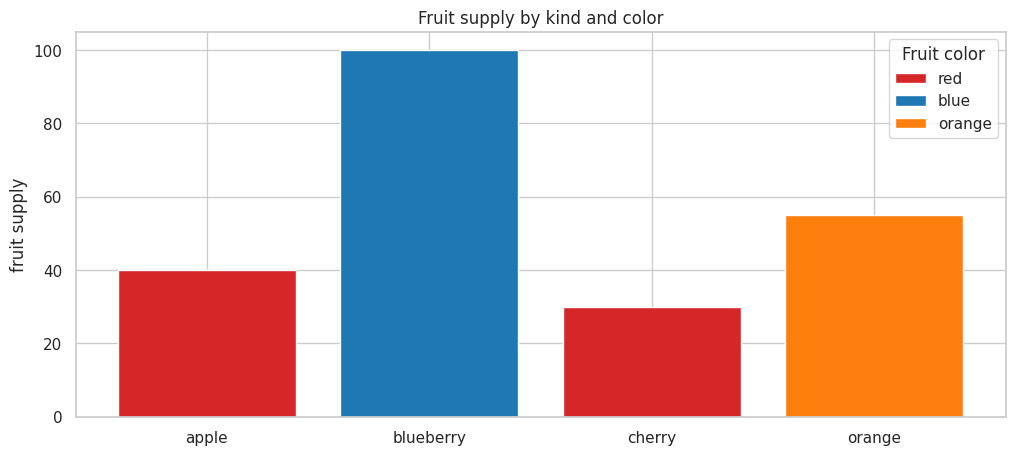

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

fruits = ['apple', 'blueberry', 'cherry', 'orange']
counts = [40, 100, 30, 55]
bar_labels = ['red', 'blue', '_red', 'orange']
bar_colors = ['tab:red', 'tab:blue', 'tab:red', 'tab:orange']

ax.bar(fruits, counts, label=bar_labels, color=bar_colors)

ax.set_ylabel('fruit supply')
ax.set_title('Fruit supply by kind and color')
ax.legend(title='Fruit color')

plt.show()

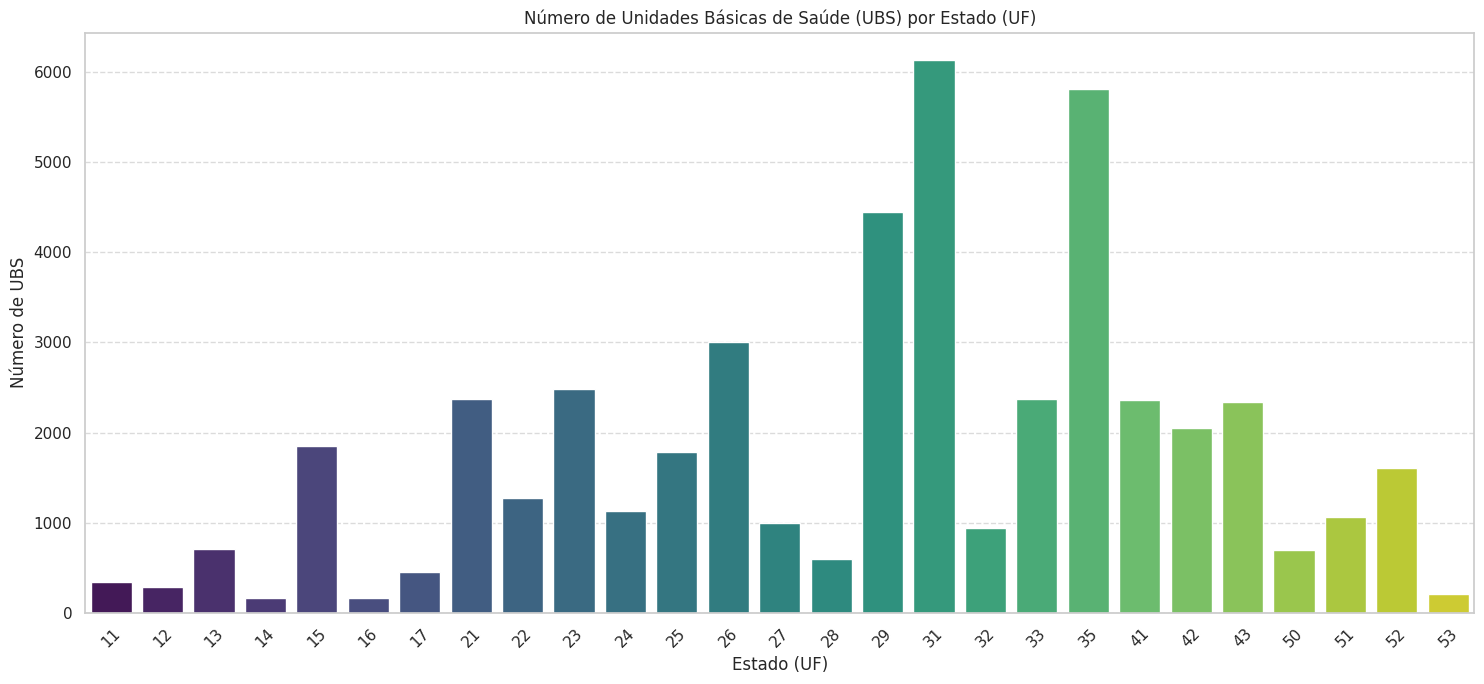

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns


ubs_per_state = df['UF'].value_counts().reset_index()
ubs_per_state.columns = ['UF', 'Count']


plt.figure(figsize=(15, 7))
sns.barplot(x='UF', y='Count', data=ubs_per_state, palette='viridis')
plt.title('Número de Unidades Básicas de Saúde (UBS) por Estado (UF)')
plt.xlabel('Estado (UF)')
plt.ylabel('Número de UBS')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

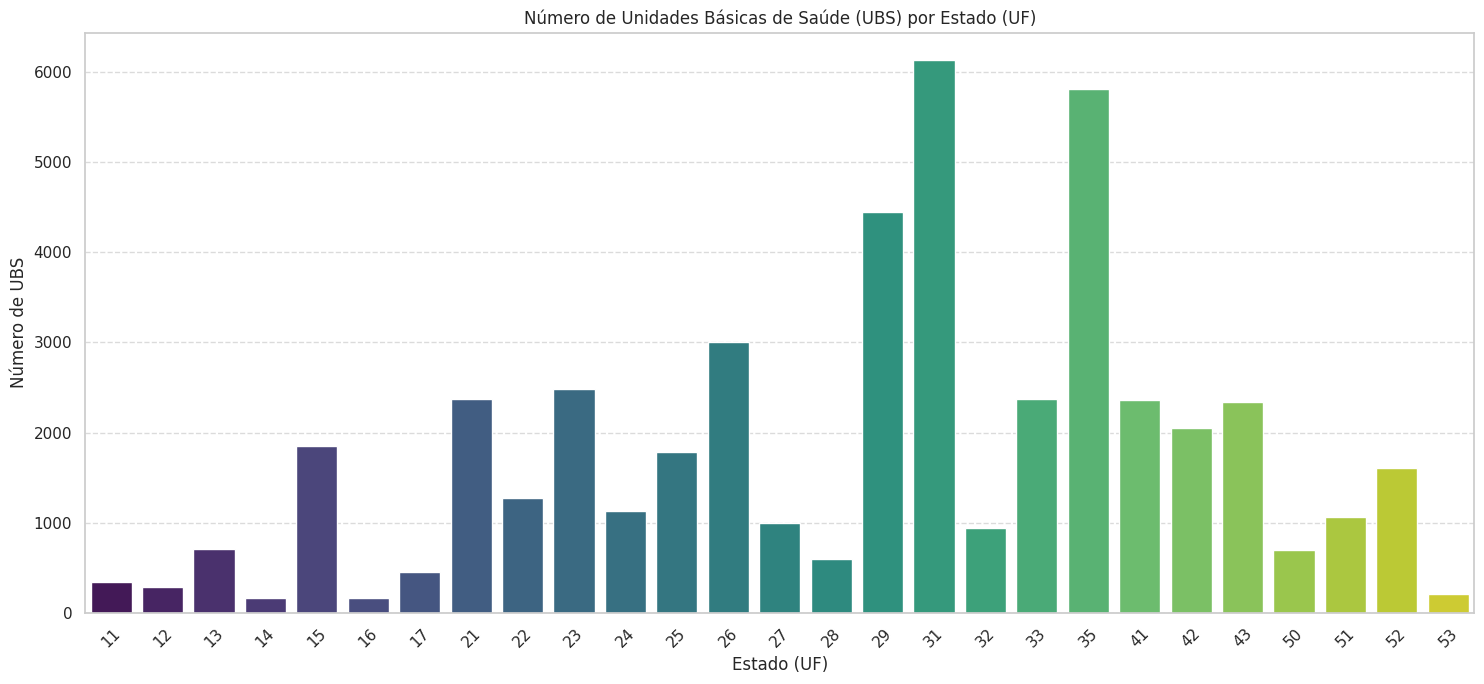

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns


ubs_per_state = df['UF'].value_counts().reset_index()
ubs_per_state.columns = ['UF', 'Count']


plt.figure(figsize=(15, 7))
sns.barplot(x='UF', y='Count', data=ubs_per_state, palette='viridis')
plt.title('Número de Unidades Básicas de Saúde (UBS) por Estado (UF)')
plt.xlabel('Estado (UF)')
plt.ylabel('Número de UBS')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [9]:
import folium
from folium.plugins import HeatMap


df['LONGITUDE'] = df['LONGITUDE'].astype(str).str.replace(',', '.').astype(float)
df_map = df.dropna(subset=['LATITUDE', 'LONGITUDE'])

#Criar Mapa de Calor da distribuição das UBS
print(f'Gerando mapa com {len(df_map)} pontos...')
mapa = folium.Map(location=[-14.235, -51.925], zoom_start=4)
heat_data = df_map[['LATITUDE', 'LONGITUDE']].values.tolist()
HeatMap(heat_data, radius=8, blur=10, max_zoom=1).add_to(mapa)

display(mapa)

Gerando mapa com 45743 pontos...


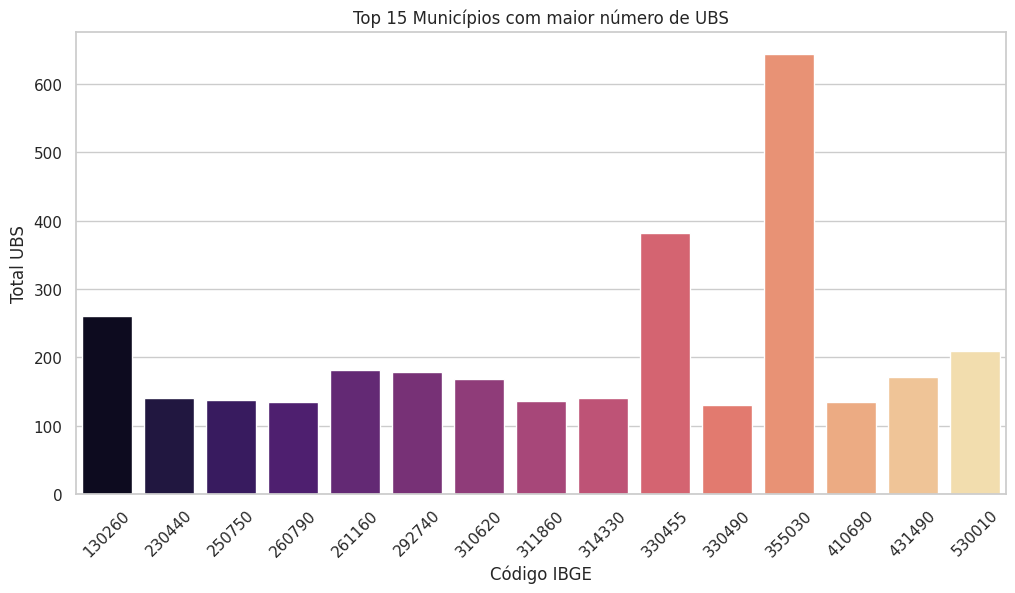

In [10]:
#Análise por Município (Top 15)
top_municipios = df['IBGE'].value_counts().head(15).reset_index()
top_municipios.columns = ['Código IBGE', 'Total UBS']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_municipios, x='Código IBGE', y='Total UBS', palette='magma')
plt.title('Top 15 Municípios com maior número de UBS')
plt.xticks(rotation=45)
plt.show()